Loading FinBERT model (downloads once, ~400MB)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully

Speech: 20,735 characters
Q&A:    53,902 characters

Speech: 9 chunks
Q&A:    24 chunks

Scoring 9 chunks for: Speech


100%|██████████| 9/9 [00:02<00:00,  4.03it/s]


Scoring 24 chunks for: Q&A


100%|██████████| 24/24 [00:00<00:00, 25.60it/s]



Total chunks scored: 33
    label  chunk                                                                                             text_preview sentiment   score
0  Speech      1  Barclays PLC Q1 2026 Results Analyst and Investor Conference Call Speech 28th April 2026 Speakers: C...   neutral  0.8874
1  Speech      2  recognise a £228 million single name charge in the first quarter. This was in our Securitised Produc...  negative  0.8616
2  Speech      3  supported by share count reduction. Operational momentum continues and we remain focused on executio...  positive  0.9594
3  Speech      4  a higher cost per claim following increases to the compensatory interest rate. Inclusive of the Moto...  positive  0.6864
4  Speech      5  growth RWAs by the end of '26, having deployed £22 billion since '24. We grew mortgage lending by £1...  positive  0.9597
5  Speech      6  with the fall versus Q4 mainly due to day count. Strong lending momentum continued and supported dep...  positive  0.

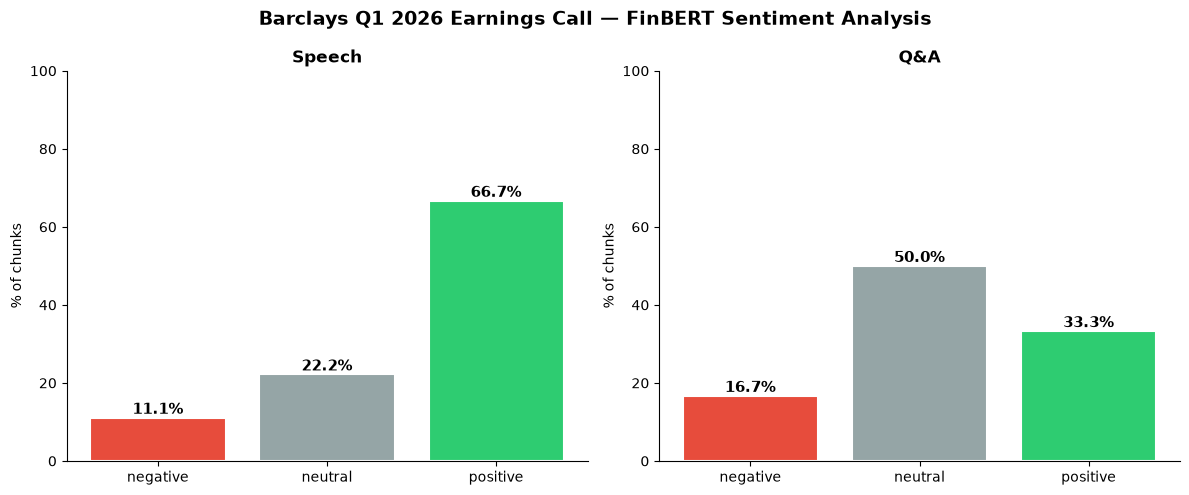

Chart saved to outputs/
Results saved to data/processed/


In [2]:
import os
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification, pipeline
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Step 1: Load FinBERT ──────────────────────────────────────────────────────

print("Loading FinBERT model (downloads once, ~400MB)...")
model_name = "ProsusAI/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
print("FinBERT loaded successfully\n")

# ── Step 2: Load transcripts ──────────────────────────────────────────────────

def load_transcript(filename):
    path = os.path.join("..", "data", "raw", filename)
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

speech = load_transcript("Barclays_Q126_EarningsCall_Speech.txt")
qa     = load_transcript("Barclays_Q126_EarningsCall_QA.txt")

print(f"Speech: {len(speech):,} characters")
print(f"Q&A:    {len(qa):,} characters\n")

# ── Step 3: Chunk the text ────────────────────────────────────────────────────

def chunk_text(text, max_words=400):
    words  = text.split()
    chunks = []
    for i in range(0, len(words), max_words):
        chunks.append(" ".join(words[i:i + max_words]))
    return chunks

speech_chunks = chunk_text(speech)
qa_chunks     = chunk_text(qa)

print(f"Speech: {len(speech_chunks)} chunks")
print(f"Q&A:    {len(qa_chunks)} chunks\n")

# ── Step 4: Run FinBERT ───────────────────────────────────────────────────────

def score_chunks(chunks, label):
    results = []
    print(f"Scoring {len(chunks)} chunks for: {label}")
    for i, chunk in enumerate(tqdm(chunks)):
        result = nlp(chunk[:512])
        results.append({
            "label":        label,
            "chunk":        i + 1,
            "text_preview": chunk[:100] + "...",
            "sentiment":    result[0]["label"],
            "score":        round(result[0]["score"], 4)
        })
    return pd.DataFrame(results)

speech_results = score_chunks(speech_chunks, "Speech")
qa_results     = score_chunks(qa_chunks,     "Q&A")
all_results    = pd.concat([speech_results, qa_results], ignore_index=True)

print(f"\nTotal chunks scored: {len(all_results)}")
print(all_results.head(10).to_string())

# ── Step 5: Aggregate ─────────────────────────────────────────────────────────

summary = all_results.groupby(["label", "sentiment"]).agg(
    count    = ("chunk", "count"),
    avg_score = ("score", "mean")
).reset_index()

totals  = all_results.groupby("label")["chunk"].count().reset_index()
totals.columns = ["label", "total"]
summary = summary.merge(totals, on="label")
summary["pct"] = (summary["count"] / summary["total"] * 100).round(1)

print("\nSentiment summary:")
print(summary.to_string(index=False))

# ── Step 6: Chart ─────────────────────────────────────────────────────────────

colours = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Barclays Q1 2026 Earnings Call — FinBERT Sentiment Analysis",
             fontsize=14, fontweight="bold")

for ax, section in zip(axes, ["Speech", "Q&A"]):
    data = summary[summary["label"] == section]
    bars = ax.bar(data["sentiment"], data["pct"],
                  color=[colours.get(s, "grey") for s in data["sentiment"]],
                  edgecolor="white", linewidth=1.5)
    ax.set_title(section, fontsize=12, fontweight="bold")
    ax.set_ylabel("% of chunks")
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, pct in zip(bars, data["pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1, f"{pct}%",
                ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/barclays_q126_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/")

# ── Step 7: Save results ──────────────────────────────────────────────────────

os.makedirs("data/processed", exist_ok=True)
all_results.to_csv("data/processed/barclays_q126_sentiment_scores.csv", index=False)
summary.to_csv("data/processed/barclays_q126_sentiment_summary.csv",    index=False)
print("Results saved to data/processed/")